# Murmuration — 3D Analysis Notebook

A runnable tour of the **3D** simulation's science modules — the same code the
live simulator uses, driven headlessly here (no window, no GPU). Everything is
three-dimensional: there is no 2D model in this project.

We look at four things:

1. **Order & opacity over time** — the flock self-organising (Pearce 2014 observables).
2. **Consensus robustness → optimal neighbour count m\*** (Young 2013).
3. **Flock shape → suggested m\*** (Young 2013, PCA).
4. **Density scaling** — how density scales with flock size N (Pearce marginal opacity).


In [1]:
import sys, os
for _p in ("..", "."):            # find the repo root whether run
    if os.path.isfile(os.path.join(_p, "flock_core.py")):  # from notebooks/ or root
        sys.path.insert(0, os.path.abspath(_p)); break
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np, random

random.seed(0); np.random.seed(0)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "figure.facecolor": "white"})
print("ready")

ready


## 1 · Order & opacity as the flock self-organises

We run the headless `World` (the same per-frame update `main_3d` uses) for a
short spell and record the Pearce observables each frame: the **order parameter**
α = |Σ v̂|/N (0 = disordered, 1 = aligned), **internal opacity** Θ and
**external opacity** Θ′, and the **dispersion** (mean distance from the centre of
mass). Birds start with random headings, so α climbs as they align.

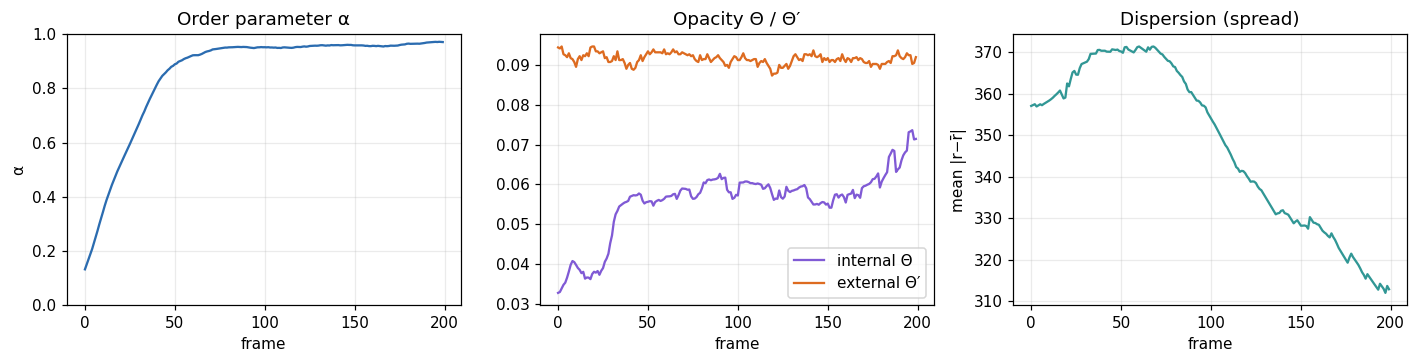

final α=0.971  Θ=0.071  Θ'=0.092


In [2]:
from simulation_3d import World
from metrics_3d import (order_parameter, internal_opacity,
                        external_opacity, dispersion)

random.seed(1); np.random.seed(1)
world = World(num_boids=80)          # projection mode by default
FRAMES = 200
alpha, theta_i, theta_e, disp = [], [], [], []
for _ in range(FRAMES):
    world.step(1/60)
    f = world.flock
    alpha.append(order_parameter(f))
    theta_i.append(internal_opacity(f))
    theta_e.append(external_opacity(f))
    disp.append(dispersion(f))

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].plot(alpha, color="#2b6cb0"); ax[0].set(title="Order parameter α",
          xlabel="frame", ylabel="α", ylim=(0, 1))
ax[1].plot(theta_i, label="internal Θ", color="#805ad5")
ax[1].plot(theta_e, label="external Θ′", color="#dd6b20")
ax[1].set(title="Opacity Θ / Θ′", xlabel="frame"); ax[1].legend()
ax[2].plot(disp, color="#319795"); ax[2].set(title="Dispersion (spread)",
          xlabel="frame", ylabel="mean |r−r̄|")
fig.tight_layout(); plt.show()
print(f"final α={alpha[-1]:.3f}  Θ={theta_i[-1]:.3f}  Θ'={theta_e[-1]:.3f}")

## 2 · Consensus robustness → optimal neighbour count m\* (Young 2013)

Young et al. model the flock as a consensus network over each bird's *m* nearest
neighbours and show the H₂ norm (how well the network rejects noise) improves with
*m* but with diminishing returns — so a finite **m\*** minimises the
robustness-per-sensing-cost trade-off. We settle a flock and sweep H₂(m).

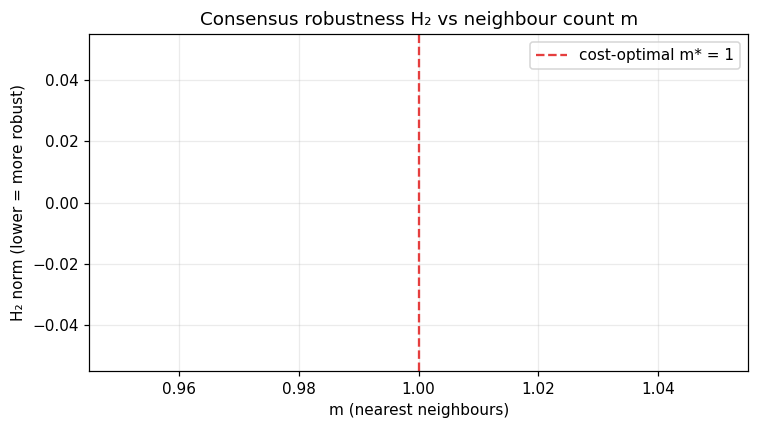

H₂ improves with m but with diminishing returns; the cost-optimal m* = 1
(m* depends on the sensing-cost weight; the shape-based m* below reproduces Young's 6–9.8 range)


In [3]:
from h2_robustness import h2_norm, cost_optimal_m
from density_scaling import settle_flock, open_boundary

with open_boundary(True):
    pts = settle_flock(90, frames=250, seed=2)   # a settled 3D flock

ms = list(range(1, 13))
h2 = [h2_norm(pts, m) for m in ms]
best_m, best_cost = cost_optimal_m(pts)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ms, h2, "o-", color="#2b6cb0")
ax.axvline(best_m, color="#e53e3e", ls="--", label=f"cost-optimal m* = {best_m}")
ax.set(title="Consensus robustness H₂ vs neighbour count m",
       xlabel="m (nearest neighbours)", ylabel="H₂ norm (lower = more robust)")
ax.legend(); fig.tight_layout(); plt.show()
print(f"H₂ improves with m but with diminishing returns; the cost-optimal m* = {best_m}")
print("(m* depends on the sensing-cost weight; the shape-based m* below reproduces Young's 6–9.8 range)")

## 3 · Flock shape → suggested m\* (PCA)

The optimal *m* also depends on flock **shape**: Young find round flocks want more
neighbours (~9.8) and thin flocks fewer (~6). `flock_shape.analyze_shape` runs a
3×3 position-covariance PCA and maps the aspect ratio to a suggested m\*.

thin    aspect=41.58  thickness=0.02  suggested m*=6.05
round   aspect= 1.22  thickness=0.82  suggested m*=9.37


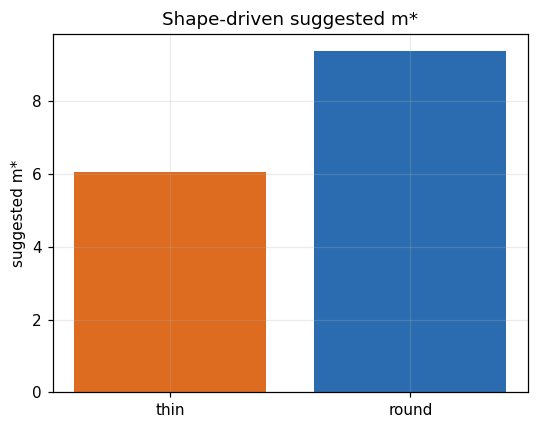

In [4]:
from flock_shape import analyze_shape

random.seed(3)
thin  = [(x, np.random.uniform(-8, 8), np.random.uniform(-8, 8))
         for x in range(0, 600, 8)]                       # a long, thin flock
round_ = [tuple(np.random.uniform(-50, 50, 3)) for _ in range(120)]  # a blob

for name, flock in [("thin", thin), ("round", round_)]:
    r = analyze_shape(flock)
    print(f"{name:6s}  aspect={r.aspect_ratio:5.2f}  "
          f"thickness={r.thickness_ratio:4.2f}  suggested m*={r.suggested_m:.2f}")

reps = {n: analyze_shape(f) for n, f in [("thin", thin), ("round", round_)]}
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(list(reps), [r.suggested_m for r in reps.values()],
       color=["#dd6b20", "#2b6cb0"])
ax.set(title="Shape-driven suggested m*", ylabel="suggested m*")
fig.tight_layout(); plt.show()

## 4 · Density scaling with flock size N (Pearce marginal opacity)

For internal opacity to stay N-independent (Pearce's *marginal opacity*), density
must scale as ρ ~ N^(−1/2). We sweep a few flock sizes in free flight and fit the
exponent. (Small N and short runs here so the notebook stays quick — see
`sci.md §4.9` for the full picture and why the current δ̂ lands nearer ρ ~ N^0.)

Density scaling (open boundary, free-flight self-sizing)
    N   spacing  density(1e6)   size Rg  Theta_ext
   40     229.8         0.094     442.3      0.045
   80     172.3         0.124     507.8      0.082
  150     123.8         0.225     514.4      0.129

fit  density ~ N^+0.656   (Pearce marginal target -0.500)
fit  size Rg ~ N^+0.116   (Pearce marginal target +0.500)

N-independent marginal opacity needs density ~ N^(-1/2); a fixed-
spacing (constant-density) flock instead gives density ~ N^0. See
sci.md §4.9 for why the current cohesion+steric δ̂ lands near the
latter and what a density-regulating δ̂ would change.


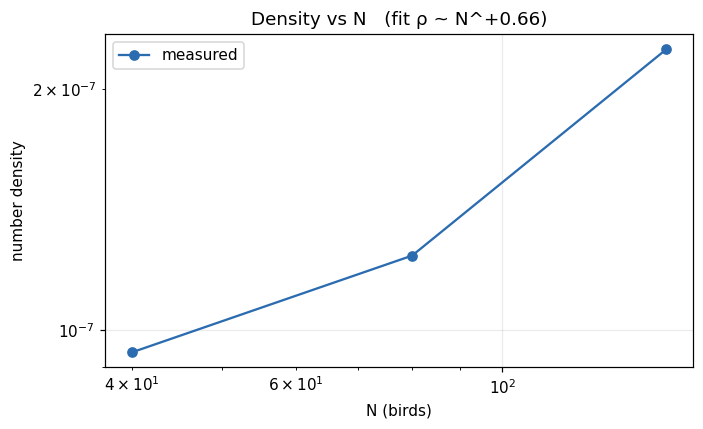

In [5]:
from density_scaling import measure_scaling, format_report

result = measure_scaling(n_values=(40, 80, 150), frames=150, seeds=(0,))
print(format_report(result))

pts = result["points"]
ns = [p["n"] for p in pts]; dens = [p["density"] for p in pts]
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.loglog(ns, dens, "o-", color="#2b6cb0", label="measured")
ax.set(title=f"Density vs N   (fit ρ ~ N^{result['density_exponent']:+.2f})",
       xlabel="N (birds)", ylabel="number density")
ax.legend(); fig.tight_layout(); plt.show()

---

Every figure above came straight from the project's 3D modules
(`simulation_3d`, `metrics_3d`, `h2_robustness`, `flock_shape`, `density_scaling`).
For the derivations and equations, see [`sci.md`](../sci.md); for the code map,
[`README.md`](../README.md).